In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

#used pandas for loading and analyzing the dataset.
#used numpy for numerical operations.
#used matplotlib and seaborn for graphs and visualization.
#used sklearn libraries for machine learning model training and evaluation.

In [4]:
df = pd.read_csv('insurance.csv')

df.head()

#loaded the loan prediction dataset and displayed first 5 rows using head() function.

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
print("Shape of dataset:", df.shape)

#checked the shape of dataset showing total rows and columns.

Shape of dataset: (1338, 7)


In [6]:
print("Columns in dataset:")
print(df.columns)

#displayed all column names present in the dataset.

Columns in dataset:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')


In [7]:
df.info()

#used info() function to check datatype and non-null values in dataset.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [8]:
df.describe()

#describe() function used to get statistical information like mean, min, max and standard deviation.

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
print(df.isnull().sum())

#checked if there is any missing value in the dataset using isnull() function.
#all columns are showing 0 which means there are no missing values present.
#dataset is already clean and ready for analysis.

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


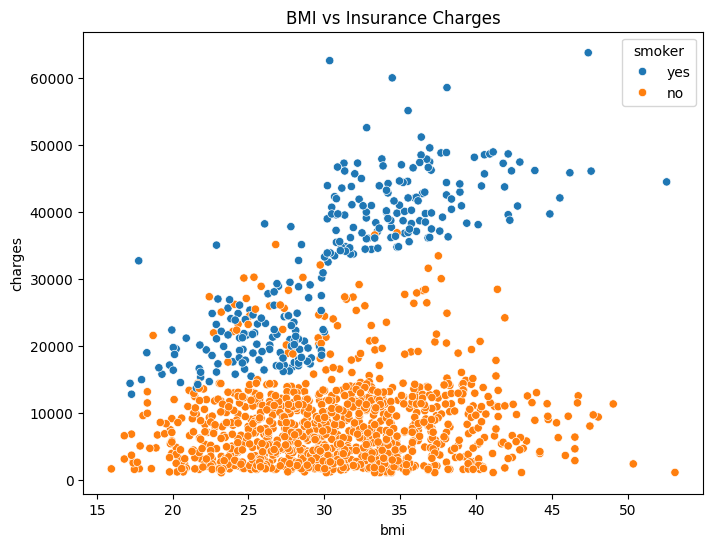

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)

plt.title("BMI vs Insurance Charges")

plt.show()

#used scatter plot to compare bmi with insurance charges.
#smokers are showing much higher insurance charges compared to non-smokers.
#insurance charges generally increase as bmi increases.

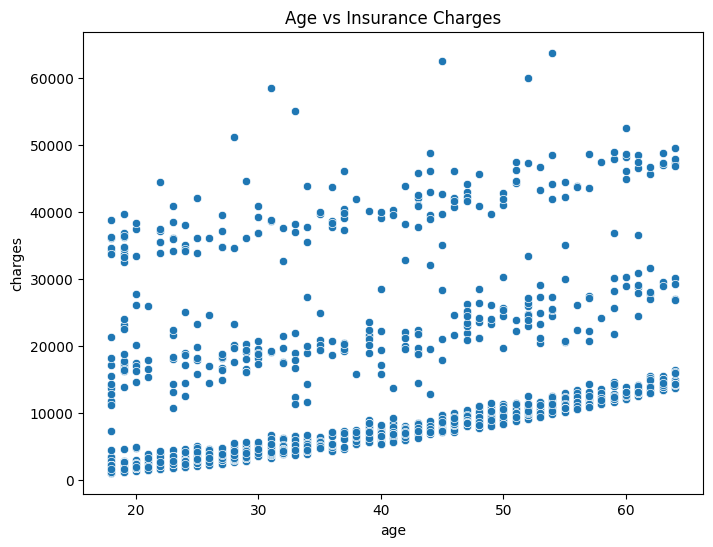

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='age', y='charges', data=df)

plt.title("Age vs Insurance Charges")

plt.show()

#used scatter plot to compare age with insurance charges.
#older people generally have higher insurance charges.
#positive relation can be seen between age and charges.

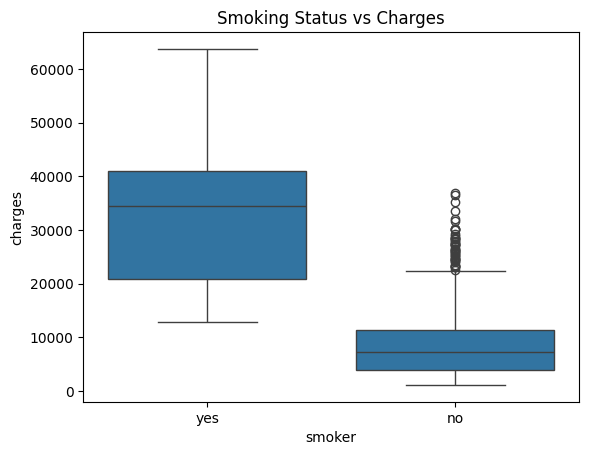

In [15]:
sns.boxplot(x='smoker', y='charges', data=df)

plt.title("Smoking Status vs Charges")

plt.show()

#used box plot to compare smoker and non-smoker charges.
#smokers have much higher insurance costs compared to non-smokers.
#shows the spread and variation in insurance charges.


In [16]:
label_encoder = LabelEncoder()

categorical_columns = ['sex', 'smoker', 'region']

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

#converted categorical text values into numerical values using label encoding.
#machine learning models cannot directly work on text data.

In [17]:
X = df.drop('charges', axis=1)

y = df['charges']

#X contains all input features.
#y contains the target variable which is insurance charges.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#split the dataset into training and testing data.
#80% data used for training and 20% data used for testing.

In [20]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

#trained the linear regression model using training data.
#used linear regression because insurance charges are numerical values.

LinearRegression()

In [21]:
y_pred = model.predict(X_test)

#predicted insurance charges using testing data.

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)

print("RMSE:", rmse)

#MAE value is showing the average prediction error in insurance charges.
#RMSE value is showing how far the predicted values are from actual values.
#lower MAE and RMSE values indicate better model performance.
#model predicted insurance charges with reasonable accuracy.

MAE: 4186.508898366433
RMSE: 5799.587091438356


In [24]:
#FINAL CONCLUSION:

#successfully predicted insurance charges using linear regression model.
#performed data cleaning, visualization and model evaluation.
#age, bmi and smoking status highly affected insurance charges.
#model achieved reasonable prediction accuracy using regression techniques.